# Analaysis of deep learning models segmentation performance for rescaled images
This notebook allows to compare the results obtained for segmentation and the ground truth across image resolutions. The notebook will compute the following metrics and provide plots to visualise the results: 
- Mean Intersection-over-Union (IoU) as described in the Cell Tracking Challenge (True positives identified with a minimum of 50% overlap).
- Object diameter
- Theoretical throughput

**Expected output**:
- A new folder (`Results`) in the main directory with `.csv`files containing the numerical data for the assessment.
- Images of true positives, false positives, and false negatives for each image.



## 1. Import dependencies

In [1]:
from rescale4dl import analyse
from rescale4dl.plot import generate_binary_semantic_box_plot_3D, plot_segmentation_example, plot_data_distributions
from rescale4dl import stats
import os
from tifffile import imread

## 2. Compile quantitative data
This cell will compute analytical measurements for all the datasets and rescaling factors contained in the given INPUT_DIR.
-  **INPUT_DIR**  
   - Path to the folder containing the input images and the annotations, stored as `.tiff`files.
   - The input directory is expected to have the following structure (preserving the naming for "GT" and "Prediction" folders)
        - **DATASET (e.g., Saureus_instance_segmentation)**
            * **OG**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
            * **downsampling_2**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
 
   - Example: `/path/to/your/input`

In [2]:
# Directory with folders of sampling folders with GT and Prediction folder pairs inside
INPUT_DIR = '/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/3DUNET/Results/organised4evaluation'


# List of sampling folders to be included in the analysis. If None, all folders in the datasets of the input directory will be included.

# DATASET_NAME = '3DUNET'
# sampling_dir_list = [f for f in os.listdir(os.path.join(INPUT_DIR, DATASET_NAME)) if os.path.isdir(os.path.join(INPUT_DIR, DATASET_NAME, f))]
# sampling_dir_list.sort()  # Sort the list alphabetically
# print("Sampling directories found:", sampling_dir_list)

# sampling_dir_list = [
#         "upsampling_16",
#         "upsampling_8",
#         "upsampling_4",
#         "upsampling_2",
#         "OG",
#         "downsampling_2",
#         "downsampling_4",
#         "downsampling_8",
#         "downsampling_16",
#     ]

# Calculate object properties statistics
analyse(INPUT_DIR,
        is_3d=True,
        run_per_object_stats = False, # True for Instance Segmentation, False for Semantic or Binary Segmentation
        save_images = False, # True to save images of the segmentation examples and data distributions, False to skip saving images and saving some memory
        sampling_dir_list = None)

Calculating properties for 3DUNET
Calculating semantic segmentation statistics for 3D volumes...
Calculating semantic segmentation statistics for testing.tif in Upsampling_z_4 with 1 files
Elapsed time: 00:01:02
Calculating semantic segmentation statistics for testing.tif in Upsampling_z_2 with 1 files
Elapsed time: 00:00:29
Calculating semantic segmentation statistics for testing.tif in Upsampling_xy_4 with 1 files
Elapsed time: 00:04:51
Calculating semantic segmentation statistics for testing.tif in Upsampling_xy_2 with 1 files
Elapsed time: 00:01:01
Calculating semantic segmentation statistics for testing.tif in OG with 1 files
Elapsed time: 00:00:12
Calculating semantic segmentation statistics for testing.tif in Downsampling_z_4 with 1 files
Elapsed time: 00:00:03
Calculating semantic segmentation statistics for testing.tif in Downsampling_z_2 with 1 files
Elapsed time: 00:00:06
Calculating semantic segmentation statistics for testing.tif in Downsampling_xyz_4 with 1 files
Elapsed 

### 2.1 Display some of the example results
Display an example ground truth labelling, the prediction and the difference between them. Expected input parameters:
1. **DATASET**  
   - Name of the dataset to display (e.g., `DATASET = "Saureus_instance_segmentation"`)
2. **SCALING**
   - Name of the folder corresponding to the scaling example to display (e.g., `SCALING = "downsampling_4"`)

In [2]:
# Plot segmentation example for a specific dataset and sampling method if save_images is True in the analyse function.
INPUT_DIR = '/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/3DUNET/Results/organised4evaluation'

DATASET = "3DUNET" 
SCALING = "Downsampling_xy_2" 


# Usage (same as before):
plot_segmentation_example(
    input_dir=INPUT_DIR,
    dataset=DATASET,
    scaling=SCALING,
    slice_axis=0,
)

No images found in the binary results directory.
Check if save_images = True in the analyse function of ReScale4DL.


## 3. Plot analytical results

### 3.1 Semantic segmentation
Example dataset: "Deepbacs_Semantic_Segmentation" (The example in this section expects section 2 to have been executed with the example data)


**Expected parameters**
1. **ANALYSIS_DIR**
   - Main directory where the DATASET folder stores all the csv files for morphology
2. **DATASET**
   - Name of the dataset, which also corresponds with its folder name, e.g., `DATASET = "Deepbacs_Semantic_Segmentation"`
3. **IMAGE_SIZES**
   - Path to the csv file containing basic information about the dataset. For the example data in the `segmentation_results` folder, the csv file can be found at `segmentation_results/DATASET/DATASET_dataset_info.csv`. For the paper results in the `analysis_results`, the csv file can be found at `analysis_results/dataset_info.csv`
4. **ORIGINAL_DATASET_FOLDERNAME**
   - The name of the folder in DATASET that corresponds to the original data. `"OG"` for the example data in `segmentation_results`; `"og"` for the example data in `"analysis_results"`.
5. **OUTPUT_DIR**
   - A directory to save the plots.
  
**Expected plots**
- IoU and Theoretical Throughput accross scales
- Barplot with diameter distributions for the ground truth and the segmentation results

In [4]:
# Plot segmentation example for a specific dataset and sampling method if save_images is True in the analyse function.
ANALYSIS_DIR = '/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/3DUNET/Results/organised4evaluation'
DATASET = "3DUNET" 
ORIGINAL_DATASET_FOLDERNAME = "OG" 
OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET, "Results", "plots")

**Run**

DONE!


/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/rescale4dl/plot.py:486: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  plot = sns.barplot(**plot_args_box)
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/rescale4dl/plot.py:486: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  plot = sns.barplot(**plot_args_box)
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/rescale4dl/plot.py:486: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  plot = sns.barplot(**plot_args_box)


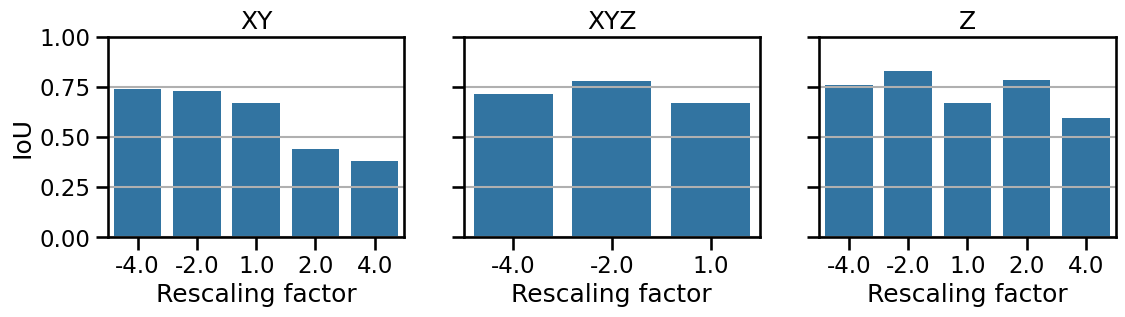

In [5]:
## Run
dataset_name_match_dict = {DATASET: DATASET}
fig_name = f"IoU for {DATASET}"
y_axis = "IoU"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Plot of accuracy metrics
generate_binary_semantic_box_plot_3D(ANALYSIS_DIR,
                                  DATASET,
                                  DATASET,
                                  fig_name, 
                                  y_axis, 
                                  thoughput_plot=False, 
                                  y_axis_2 = "Obj_per_FOV_mean",
                                  plot_type="barplot"
                                  )

## 4. Statistical analysis
Calculate basic data distribution values and compare distributions accross different rescaling factors.
These can be calculated with the example data as follows:
1. **DATASET**
    - One of the following ones:
        - `"Saureus_instance_segmentation", "Deepbacs_Instance_Segmentation", "Deepbacs_Semantic_Segmentation", "Saureus_instance_segmentation_pc190723", "Saureus_instance_segmentation", "Worm_Semantic_Segmentation"`
2. **ANALYSIS_DIR**
    - The absolute path to `"Examples/analysis_results"`
3. **QUNATITATIVE_COLUMN**
    - Typically `"IoU"`. However, one can choose to compare other metrics such as `"f1_score", "pred_diameter_median", "pred_area", "Sensitivity", "pred_Circularity", "Accuracy"`. 
4. **CATEGORICAL_COLUMN**
    - List of column names dividing the data in groups for comparison. E.g., `["Grand_Parent_Folder"]`.
5. **TEST_TYPE**
    - `"t-test"`: When both groups are normally distributed and have equal variances.
    - `"Welch's t-test"`: When both groups are normally distributed and have unequal variances.
    - `"Kolmogorov-Smirnov"`: When at least one of the variables is not normally distributed. 
6. **TEST_CHOICE** 
  - `"Automatic"` if you want to run an automatic testing based on assessed properties of the data distribution. 
  - `"Manual"` to manually indicate what test to run.




Error computing statistical analysis: zero-size array to reduction operation maximum which has no identity. Please check that n>1 for each group.


/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/

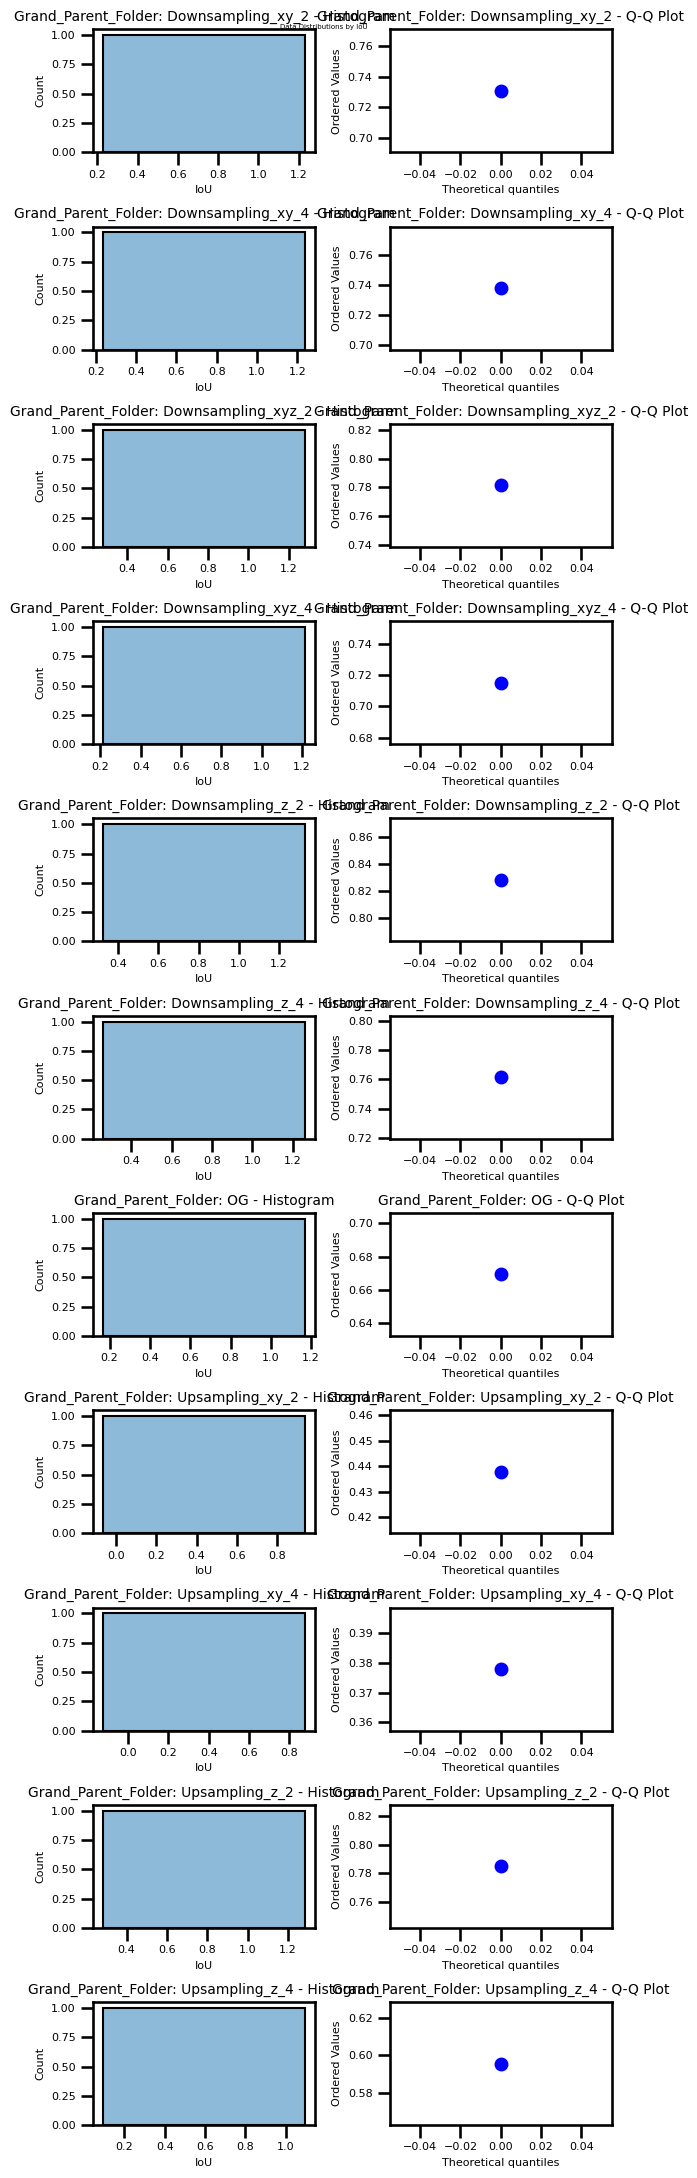

In [4]:
## Input variables for stats
DATASET = "3DUNET"
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/3DUNET/Results/organised4evaluation"
QUANTITATIVE_COLUMN = "IoU"
CATEGORICAL_COLUMN = ["Grand_Parent_Folder"]
TEST_TYPE = "Kolmogorov-Smirnov" # "t-test"
TEST_CHOICE = "Automatic" # "Manual" 
FILENAME = "binary_mask_stats.csv" # "summary_stats.csv"

## Uncomment the following lines to print a summary of the data
# import pandas as pd
# df = pd.read_csv(os.path.join(ANALYSIS_DIR, DATASET, "Results", f"{DATASET}_{FILENAME}"))
# print(df.groupby(CATEGORICAL_COLUMN)[QUANTITATIVE_COLUMN].describe())


## Compute statistical tests
try:
    results = stats.compute_statistical_analysis(ANALYSIS_DIR,
                                                DATASET,
                                                QUANTITATIVE_COLUMN,
                                                CATEGORICAL_COLUMN,
                                                filename = FILENAME,
                                                test_type=TEST_TYPE,
                                                choose_test=TEST_CHOICE)
except Exception as e:
    print(f"Error computing statistical analysis: {e}. Please check that n>1 for each group.")
    results = None  
try:
    plot_data_distributions(ANALYSIS_DIR,
                            DATASET,
                            QUANTITATIVE_COLUMN,
                            CATEGORICAL_COLUMN,
                            filename = FILENAME)
except Exception as e:
    print(f"Error plotting data distributions: {e}")
results